# Word2Vec: From Theory to Implementation
## A Complete Guide to Distributed Word Representations

---

### Table of Contents

1. **Introduction** — Why Word Embeddings?
2. **The Word2Vec Framework** — Core Intuition
3. **CBOW Architecture** — Predict the Center from Context
4. **Skip-gram Architecture** — Predict Context from the Center
5. **Mathematical Foundations** — Objective Functions & Optimization
6. **Training Tricks** — Negative Sampling, Subsampling, Hierarchical Softmax
7. **Implementation from Scratch** — PyTorch Code
8. **Industrial Applications** — Beyond NLP

---

## 1. Introduction: Why Word Embeddings?

Traditional NLP represented words as **one-hot vectors** — sparse, high-dimensional vectors where each word is orthogonal to every other. This representation suffers from two fatal flaws:

* **Curse of dimensionality**: Vocabulary size $$V$$ can be 100K–1M, making each vector enormous
* **No semantic similarity**: $$\cos(\text{one-hot}(\text{king}), \text{one-hot}(\text{queen})) = 0$$

**Word embeddings** solve this by mapping words into a dense, low-dimensional continuous vector space (typically $$d = 50$$ to $$300$$) where **semantically similar words are geometrically close**.

The breakthrough insight of Word2Vec (Mikolov et al., 2013) was:

> *"You shall know a word by the company it keeps."* — J.R. Firth (1957)

Word2Vec learns representations purely from **co-occurrence patterns** in large text corpora, requiring no labeled data.

## 2. The Word2Vec Framework — Core Intuition

Word2Vec is not a single model but a **family of architectures** for learning word vectors. The key idea:

> Given a word in a sentence, either **predict its surrounding context** (Skip-gram) or **predict the word from its context** (CBOW).

### The Distributional Hypothesis

Words that appear in similar contexts have similar meanings. Consider:

* "The **cat** sat on the mat"
* "The **dog** sat on the mat"

Since "cat" and "dog" share almost identical contexts, their learned vectors will be close in the embedding space.

### Architecture Overview

| Property | CBOW | Skip-gram |
| --- | --- | --- |
| Input | Context words (surrounding) | Center word |
| Output | Center word (target) | Context words |
| Speed | Faster (single prediction) | Slower (multiple predictions) |
| Rare words | Worse (context averaging) | Better (each pair is a sample) |
| Best for | Frequent words, large corpora | Small corpora, rare words |

Both architectures share the same fundamental structure: a **shallow neural network** with one hidden layer, where the learned weight matrices ARE the word embeddings.

## 3. Continuous Bag of Words (CBOW)

### Architecture

CBOW predicts the **center word** given a window of **context words**. The architecture is:

```
Input Layer          Hidden Layer         Output Layer
(one-hot context)    (projection)         (softmax over vocab)

  w(t-2) ──┐
           ├──── AVG/SUM ──────── Softmax ────▶ w(t)
  w(t-1) ──┤           (h)              P(w|context)
           ├────
  w(t+1) ──┤
           ├────
  w(t+2) ──┘
```

### Mathematical Formulation

**Notation:**
* $$V$$ = vocabulary size
* $$d$$ = embedding dimension
* $$C$$ = context window size (number of words on each side)
* $$\mathbf{W} \in \mathbb{R}^{V \times d}$$ = input embedding matrix (rows are word vectors)
* $$\mathbf{W'} \in \mathbb{R}^{d \times V}$$ = output embedding matrix
* $$w_t$$ = center (target) word at position $$t$$
* $$w_{t+j}$$ for $$j \in \{-C, ..., -1, 1, ..., C\}$$ = context words

**Step 1: Input Representation**

Each context word $$w_{t+j}$$ is represented as a one-hot vector $$\mathbf{x}_{t+j} \in \mathbb{R}^V$$. The embedding lookup retrieves:

$$\mathbf{v}_{w_{t+j}} = \mathbf{W}^\top \mathbf{x}_{t+j}$$

This is simply selecting the row of $$\mathbf{W}$$ corresponding to that word.

**Step 2: Hidden Layer (Context Aggregation)**

The hidden layer computes the **average** of all context word embeddings:

$$\mathbf{h} = \frac{1}{2C} \sum_{j=-C, j\neq 0}^{C} \mathbf{v}_{w_{t+j}}$$

Note: There are **no non-linear activation functions** in the hidden layer. This is crucial — Word2Vec is a **linear model** in disguise.

**Step 3: Output Layer (Score Computation)**

The score for each vocabulary word $$w_i$$ being the center word is:

$$u_i = \mathbf{W'}_{:,i}^\top \cdot \mathbf{h}$$

where $$\mathbf{W'}_{:,i}$$ is the $$i$$-th column of the output matrix.

**Step 4: Softmax Probability**

$$P(w_t | w_{t-C}, ..., w_{t+C}) = \frac{\exp(u_{w_t})}{\sum_{i=1}^{V} \exp(u_i)} = \frac{\exp(\mathbf{v'}_{w_t}^\top \mathbf{h})}{\sum_{i=1}^{V} \exp(\mathbf{v'}_i^\top \mathbf{h})}$$

**Step 5: Loss Function**

The objective is to **maximize** the log-likelihood:

$$\mathcal{L}_{\text{CBOW}} = \frac{1}{T} \sum_{t=1}^{T} \log P(w_t | w_{t-C}, ..., w_{t+C})$$

Equivalently, minimize the negative log-likelihood (cross-entropy loss):

$$J = -\frac{1}{T} \sum_{t=1}^{T} \log P(w_t | \text{context}(w_t))$$

### Gradient Derivation (CBOW)

For a single training example, the loss is:

$$E = -\log P(w_t | \text{context}) = -u_{w_t} + \log \sum_{i=1}^{V} \exp(u_i)$$

The gradient w.r.t. the output vector $$\mathbf{v'}_{w_i}$$:

$$\frac{\partial E}{\partial \mathbf{v'}_i} = (\hat{y}_i - y_i) \cdot \mathbf{h}$$

where $$\hat{y}_i = P(w_i | \text{context})$$ is the predicted probability and $$y_i$$ is 1 if $$i = w_t$$, else 0.

The gradient w.r.t. the hidden layer:

$$\frac{\partial E}{\partial \mathbf{h}} = \sum_{i=1}^{V} (\hat{y}_i - y_i) \cdot \mathbf{v'}_i = \mathbf{W'} (\hat{\mathbf{y}} - \mathbf{y})$$

This is then back-propagated equally to each context word's input embedding.

## 4. Skip-gram Architecture

### Architecture

Skip-gram is the **mirror image** of CBOW: given the center word, predict each context word independently.

```
Input Layer          Hidden Layer         Output Layer
(one-hot center)     (projection)         (softmax per context word)

                                      ┌── P(w(t-2)|w(t))
                                      ├── P(w(t-1)|w(t))
  w(t) ────────── Embed(w_t) ───────┤
                      (h = v_wt)      ├── P(w(t+1)|w(t))
                                      └── P(w(t+2)|w(t))
```

### Mathematical Formulation

**Step 1: Input Representation**

The center word $$w_t$$ is mapped to its embedding:

$$\mathbf{h} = \mathbf{v}_{w_t} = \mathbf{W}^\top \mathbf{x}_t$$

Note: Unlike CBOW, there is **no averaging** — the hidden layer IS the embedding of the single center word.

**Step 2: Output Prediction**

For each context position $$j \in \{-C, ..., -1, 1, ..., C\}$$, predict:

$$P(w_{t+j} | w_t) = \frac{\exp(\mathbf{v'}_{w_{t+j}}^\top \mathbf{v}_{w_t})}{\sum_{i=1}^{V} \exp(\mathbf{v'}_i^\top \mathbf{v}_{w_t})}$$

**Step 3: Objective Function**

Maximize the total log probability of observing all context words across the entire corpus:

$$\mathcal{L}_{\text{Skip-gram}} = \frac{1}{T} \sum_{t=1}^{T} \sum_{\substack{j=-C \\ j \neq 0}}^{C} \log P(w_{t+j} | w_t)$$

Equivalently, minimize:

$$J = -\frac{1}{T} \sum_{t=1}^{T} \sum_{\substack{j=-C \\ j \neq 0}}^{C} \log P(w_{t+j} | w_t)$$

### Key Difference: Number of Training Samples

For a single position $$t$$ with context window $$C$$:
* **CBOW**: generates **1** training example (all context → center)
* **Skip-gram**: generates **2C** training examples (center → each context word)

This is why Skip-gram produces more training signal per word, especially benefiting rare words.

### Gradient Derivation (Skip-gram)

For a single (center, context) pair $$(w_t, w_{t+j})$$:

$$E = -\log P(w_{t+j} | w_t) = -\mathbf{v'}_{w_{t+j}}^\top \mathbf{v}_{w_t} + \log \sum_{i=1}^{V} \exp(\mathbf{v'}_i^\top \mathbf{v}_{w_t})$$

Gradient w.r.t. output embedding $$\mathbf{v'}_i$$:

$$\frac{\partial E}{\partial \mathbf{v'}_i} = (\hat{y}_i - y_i) \cdot \mathbf{v}_{w_t}$$

Gradient w.r.t. input embedding $$\mathbf{v}_{w_t}$$:

$$\frac{\partial E}{\partial \mathbf{v}_{w_t}} = \sum_{i=1}^{V} (\hat{y}_i - y_i) \cdot \mathbf{v'}_i$$

The update for the input embedding aggregates errors from ALL vocabulary words — this is why the full softmax is computationally prohibitive.

## 5. Training Tricks — Making Word2Vec Scalable

The full softmax denominator $$\sum_{i=1}^{V} \exp(\mathbf{v'}_i^\top \mathbf{h})$$ requires computing scores for ALL $$V$$ words (often 100K+). This is the computational bottleneck. Three techniques address this:

---

### 5.1 Negative Sampling (NEG)

**Core Idea:** Instead of updating ALL output vectors, only update a small sample of "negative" (incorrect) words.

The objective for a single positive pair $$(w_t, w_c)$$ with $$K$$ negative samples becomes:

$$\mathcal{L}_{\text{NEG}} = \log \sigma(\mathbf{v'}_{w_c}^\top \mathbf{v}_{w_t}) + \sum_{k=1}^{K} \mathbb{E}_{w_k \sim P_n(w)} \left[ \log \sigma(-\mathbf{v'}_{w_k}^\top \mathbf{v}_{w_t}) \right]$$

where:
* $$\sigma(x) = \frac{1}{1+e^{-x}}$$ is the sigmoid function
* $$P_n(w)$$ is the noise distribution (negative sampling distribution)
* $$K$$ = number of negative samples (typically 5–20 for small datasets, 2–5 for large)

**Intuition:** Push the center word's vector **closer** to true context words and **farther** from randomly sampled non-context words.

**The Noise Distribution:**

Mikolov et al. found empirically that the best noise distribution is:

$$P_n(w) = \frac{f(w)^{3/4}}{\sum_{w'} f(w')^{3/4}}$$

where $$f(w)$$ is the unigram frequency. The $$3/4$$ power smooths the distribution — it gives rare words slightly higher sampling probability than their raw frequency, while still keeping frequent words dominant.

---

### 5.2 Hierarchical Softmax

**Core Idea:** Replace the flat softmax with a binary tree (Huffman tree) where each word is a leaf. The probability of a word is the product of binary decisions along the path from root to leaf.

For a word $$w$$ at leaf node, with path nodes $$n(w,1), n(w,2), ..., n(w,L)$$:

$$P(w | \mathbf{h}) = \prod_{l=1}^{L-1} \sigma\left( [\![n(w,l+1) = \text{left-child}(n(w,l))]\!] \cdot \mathbf{v'}_{n(w,l)}^\top \mathbf{h} \right)$$

where $$[\![\cdot]\!]$$ equals +1 if true, -1 if false.

**Complexity:** Reduces from $$O(V)$$ to $$O(\log V)$$ per prediction.

---

### 5.3 Subsampling of Frequent Words

Very frequent words ("the", "is", "a") provide less information. Each word $$w_i$$ in the training set is discarded with probability:

$$P(\text{discard } w_i) = 1 - \sqrt{\frac{t}{f(w_i)}}$$

where $$t$$ is a threshold (typically $$10^{-5}$$) and $$f(w_i)$$ is the word's frequency. This aggressively subsamples frequent words while keeping rare words.

---

### 5.4 Comparison of Approaches

| Technique | Complexity | Quality | When to Use |
| --- | --- | --- | --- |
| Full Softmax | $$O(V)$$ | Best (theoretical) | Tiny vocabularies only |
| Hierarchical Softmax | $$O(\log V)$$ | Good for rare words | Medium vocab, heterogeneous freq |
| Negative Sampling | $$O(K)$$ | Best empirically | Large vocab, most use cases |

In [0]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import Counter
import re
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ============================================================
# DATA PREPARATION
# ============================================================

# Sample corpus for demonstration
corpus = [
    "the king rules the kingdom with wisdom and power",
    "the queen rules the kingdom with grace and wisdom",
    "a prince will become king one day",
    "the princess will become queen one day",
    "the man works hard every day in the field",
    "the woman works hard every day at home",
    "a boy grows into a man over time",
    "a girl grows into a woman over time",
    "the king and queen rule the kingdom together",
    "the prince and princess play in the castle garden",
    "wisdom and power are needed to rule a kingdom",
    "the king has great power and the queen has great wisdom",
    "every man and woman should seek wisdom",
    "the boy wants to be a strong man like the king",
    "the girl wants to be a wise woman like the queen",
    "kings and queens have ruled kingdoms for centuries",
    "the prince trains with the king every morning",
    "the princess studies with the queen every evening",
    "a kingdom needs both a king and a queen",
    "men and women work together to build the kingdom",
]


def preprocess_corpus(corpus: List[str], min_freq: int = 1) -> Tuple[List[List[str]], Dict, Dict]:
    """Tokenize, build vocabulary, and encode the corpus."""
    # Tokenize
    tokenized = [sentence.lower().split() for sentence in corpus]
    
    # Count word frequencies
    word_counts = Counter(word for sentence in tokenized for word in sentence)
    
    # Filter by minimum frequency
    vocab = [word for word, count in word_counts.items() if count >= min_freq]
    
    # Build word-to-index and index-to-word mappings
    word2idx = {word: idx for idx, word in enumerate(vocab)}
    idx2word = {idx: word for word, idx in word2idx.items()}
    
    # Filter sentences to only include vocab words
    tokenized = [[w for w in sent if w in word2idx] for sent in tokenized]
    
    print(f"Vocabulary size: {len(vocab)}")
    print(f"Total tokens: {sum(len(s) for s in tokenized)}")
    print(f"Sample vocab: {vocab[:15]}")
    
    return tokenized, word2idx, idx2word


tokenized_corpus, word2idx, idx2word = preprocess_corpus(corpus)
VOCAB_SIZE = len(word2idx)
print(f"\nVocab size (V): {VOCAB_SIZE}")

Vocabulary size: 66
Total tokens: 173
Sample vocab: ['the', 'king', 'rules', 'kingdom', 'with', 'wisdom', 'and', 'power', 'queen', 'grace', 'a', 'prince', 'will', 'become', 'one']

Vocab size (V): 66


In [0]:
# ============================================================
# GENERATE TRAINING PAIRS
# ============================================================

def generate_cbow_pairs(tokenized_corpus: List[List[str]], word2idx: Dict, window_size: int = 2) -> List[Tuple]:
    """
    Generate (context_indices, target_index) pairs for CBOW.
    Context = surrounding words, Target = center word.
    """
    pairs = []
    for sentence in tokenized_corpus:
        indices = [word2idx[w] for w in sentence]
        for center_pos in range(window_size, len(indices) - window_size):
            context = []
            for j in range(-window_size, window_size + 1):
                if j != 0:
                    context.append(indices[center_pos + j])
            target = indices[center_pos]
            pairs.append((context, target))
    return pairs


def generate_skipgram_pairs(tokenized_corpus: List[List[str]], word2idx: Dict, window_size: int = 2) -> List[Tuple]:
    """
    Generate (center_index, context_index) pairs for Skip-gram.
    Each center word paired with each individual context word.
    """
    pairs = []
    for sentence in tokenized_corpus:
        indices = [word2idx[w] for w in sentence]
        for center_pos in range(window_size, len(indices) - window_size):
            center = indices[center_pos]
            for j in range(-window_size, window_size + 1):
                if j != 0:
                    context = indices[center_pos + j]
                    pairs.append((center, context))
    return pairs


WINDOW_SIZE = 2

cbow_pairs = generate_cbow_pairs(tokenized_corpus, word2idx, WINDOW_SIZE)
skipgram_pairs = generate_skipgram_pairs(tokenized_corpus, word2idx, WINDOW_SIZE)

print(f"CBOW training pairs: {len(cbow_pairs)}")
print(f"Skip-gram training pairs: {len(skipgram_pairs)}")
print(f"\nRatio (Skip-gram/CBOW): {len(skipgram_pairs)/len(cbow_pairs):.1f}x")
print(f"(Expected: {2*WINDOW_SIZE}x since Skip-gram generates 2C pairs per position)")

# Show example pairs
print(f"\n--- CBOW Example ---")
ctx, tgt = cbow_pairs[0]
print(f"Context: {[idx2word[i] for i in ctx]} -> Target: {idx2word[tgt]}")

print(f"\n--- Skip-gram Example ---")
center, ctx = skipgram_pairs[0]
print(f"Center: {idx2word[center]} -> Context: {idx2word[ctx]}")

CBOW training pairs: 93
Skip-gram training pairs: 372

Ratio (Skip-gram/CBOW): 4.0x
(Expected: 4x since Skip-gram generates 2C pairs per position)

--- CBOW Example ---
Context: ['the', 'king', 'the', 'kingdom'] -> Target: rules

--- Skip-gram Example ---
Center: rules -> Context: the


In [0]:
# ============================================================
# CBOW MODEL - FROM SCRATCH
# ============================================================

class CBOW(nn.Module):
    """
    Continuous Bag of Words (CBOW) model.
    
    Architecture:
        Input (2C one-hot vectors) -> Embedding Lookup -> Average -> Linear -> Softmax
        
    The embedding layer IS the word vector matrix W (V x d).
    The linear layer IS the output matrix W' (d x V).
    """
    
    def __init__(self, vocab_size: int, embedding_dim: int):
        super(CBOW, self).__init__()
        
        # Input embedding matrix W: maps word index -> dense vector
        # This is the PRIMARY word embedding we care about
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        
        # Output linear layer W': projects from embedding space to vocab
        self.linear = nn.Linear(embedding_dim, vocab_size, bias=False)
        
        # Initialize weights (Xavier uniform for better convergence)
        nn.init.xavier_uniform_(self.embeddings.weight)
        nn.init.xavier_uniform_(self.linear.weight)
    
    def forward(self, context_indices: torch.Tensor) -> torch.Tensor:
        """
        Forward pass for CBOW.
        
        Args:
            context_indices: Tensor of shape (batch_size, 2*C) containing
                           indices of context words
        
        Returns:
            Log-probabilities over vocabulary (batch_size, V)
        """
        # Step 1: Look up embeddings for all context words
        # Shape: (batch_size, 2C, embedding_dim)
        embeds = self.embeddings(context_indices)
        
        # Step 2: Average the context embeddings (the "bag of words" aggregation)
        # Shape: (batch_size, embedding_dim)
        hidden = embeds.mean(dim=1)
        
        # Step 3: Project to vocabulary space
        # Shape: (batch_size, vocab_size)
        output = self.linear(hidden)
        
        # Step 4: Log-softmax for numerical stability with NLLLoss
        log_probs = torch.log_softmax(output, dim=1)
        
        return log_probs
    
    def get_embedding(self, word_idx: int) -> np.ndarray:
        """Retrieve the learned embedding for a word."""
        return self.embeddings.weight[word_idx].detach().numpy()
    
    def get_all_embeddings(self) -> np.ndarray:
        """Retrieve the full embedding matrix."""
        return self.embeddings.weight.detach().numpy()


# Instantiate the model
EMBEDDING_DIM = 50
cbow_model = CBOW(VOCAB_SIZE, EMBEDDING_DIM)

print(f"CBOW Model Architecture:")
print(f"{'='*50}")
print(cbow_model)
print(f"{'='*50}")
print(f"\nInput embedding matrix W:  {VOCAB_SIZE} x {EMBEDDING_DIM} = {VOCAB_SIZE * EMBEDDING_DIM:,} parameters")
print(f"Output projection matrix W': {EMBEDDING_DIM} x {VOCAB_SIZE} = {EMBEDDING_DIM * VOCAB_SIZE:,} parameters")
print(f"Total parameters: {sum(p.numel() for p in cbow_model.parameters()):,}")

CBOW Model Architecture:
CBOW(
  (embeddings): Embedding(66, 50)
  (linear): Linear(in_features=50, out_features=66, bias=False)
)

Input embedding matrix W:  66 x 50 = 3,300 parameters
Output projection matrix W': 50 x 66 = 3,300 parameters
Total parameters: 6,600


In [0]:
# ============================================================
# SKIP-GRAM WITH NEGATIVE SAMPLING (SGNS) - FROM SCRATCH
# ============================================================

class SkipGramNegativeSampling(nn.Module):
    """
    Skip-gram model with Negative Sampling.
    
    Instead of full softmax over V words, we:
    1. Maximize dot product between center and TRUE context word
    2. Minimize dot product between center and K RANDOM (negative) words
    
    This reduces per-sample computation from O(V) to O(K).
    """
    
    def __init__(self, vocab_size: int, embedding_dim: int):
        super(SkipGramNegativeSampling, self).__init__()
        
        # Input (center word) embeddings
        self.center_embeddings = nn.Embedding(vocab_size, embedding_dim)
        
        # Output (context word) embeddings - separate set!
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim)
        
        # Initialize: small random values
        nn.init.xavier_uniform_(self.center_embeddings.weight)
        # Context embeddings initialized to zero (as in original paper)
        nn.init.zeros_(self.context_embeddings.weight)
    
    def forward(self, center_idx: torch.Tensor, context_idx: torch.Tensor, 
                negative_idx: torch.Tensor) -> torch.Tensor:
        """
        Compute the negative sampling loss.
        
        Args:
            center_idx:   (batch_size,) - center word indices
            context_idx:  (batch_size,) - positive context word indices
            negative_idx: (batch_size, K) - negative sample indices
        
        Returns:
            Scalar loss
        """
        # Get embeddings
        center_embeds = self.center_embeddings(center_idx)      # (B, d)
        context_embeds = self.context_embeddings(context_idx)    # (B, d)
        negative_embeds = self.context_embeddings(negative_idx)  # (B, K, d)
        
        # Positive score: dot product of center and true context
        # sigma(v'_c . v_w) should be HIGH (close to 1)
        positive_score = torch.sum(center_embeds * context_embeds, dim=1)  # (B,)
        positive_loss = -torch.log(torch.sigmoid(positive_score) + 1e-10)  # (B,)
        
        # Negative score: dot product of center and negative samples
        # sigma(-v'_neg . v_w) should be HIGH (meaning dot product is LOW)
        # center_embeds: (B, d) -> (B, 1, d) for broadcasting
        negative_score = torch.bmm(negative_embeds, center_embeds.unsqueeze(2)).squeeze(2)  # (B, K)
        negative_loss = -torch.log(torch.sigmoid(-negative_score) + 1e-10)  # (B, K)
        
        # Total loss = positive loss + sum of negative losses
        loss = positive_loss + negative_loss.sum(dim=1)
        
        return loss.mean()
    
    def get_embedding(self, word_idx: int) -> np.ndarray:
        """Retrieve the learned center embedding for a word."""
        return self.center_embeddings.weight[word_idx].detach().numpy()
    
    def get_all_embeddings(self) -> np.ndarray:
        """Retrieve the full center embedding matrix."""
        return self.center_embeddings.weight.detach().numpy()


# Instantiate
skipgram_model = SkipGramNegativeSampling(VOCAB_SIZE, EMBEDDING_DIM)

print(f"Skip-gram (Negative Sampling) Architecture:")
print(f"{'='*50}")
print(skipgram_model)
print(f"{'='*50}")
print(f"\nCenter embeddings:  {VOCAB_SIZE} x {EMBEDDING_DIM} = {VOCAB_SIZE * EMBEDDING_DIM:,} params")
print(f"Context embeddings: {VOCAB_SIZE} x {EMBEDDING_DIM} = {VOCAB_SIZE * EMBEDDING_DIM:,} params")
print(f"Total parameters: {sum(p.numel() for p in skipgram_model.parameters()):,}")
print(f"\nNote: We maintain TWO embedding matrices. The center embeddings")
print(f"      are typically used as the final word vectors.")

Skip-gram (Negative Sampling) Architecture:
SkipGramNegativeSampling(
  (center_embeddings): Embedding(66, 50)
  (context_embeddings): Embedding(66, 50)
)

Center embeddings:  66 x 50 = 3,300 params
Context embeddings: 66 x 50 = 3,300 params
Total parameters: 6,600

Note: We maintain TWO embedding matrices. The center embeddings
      are typically used as the final word vectors.


In [0]:
# ============================================================
# NEGATIVE SAMPLING DISTRIBUTION
# ============================================================

class NegativeSampler:
    """
    Implements the noise distribution P_n(w) = f(w)^(3/4) / Z
    for drawing negative samples.
    
    The 3/4 power is the key insight from Mikolov et al.:
    - Pure unigram (power=1): too biased toward frequent words
    - Uniform (power=0): doesn't respect frequency at all
    - Power 3/4: empirically optimal balance
    """
    
    def __init__(self, word2idx: Dict, tokenized_corpus: List[List[str]], power: float = 0.75):
        self.vocab_size = len(word2idx)
        
        # Count word frequencies
        word_counts = Counter(word for sentence in tokenized_corpus for word in sentence)
        
        # Build frequency array in vocabulary order
        freqs = np.array([word_counts.get(word, 0) for word in word2idx.keys()], dtype=np.float64)
        
        # Apply the 3/4 power transformation
        powered_freqs = freqs ** power
        
        # Normalize to get probabilities
        self.sampling_probs = powered_freqs / powered_freqs.sum()
        
        # Pre-compute for display
        self.freqs = freqs
        self.power = power
    
    def sample(self, batch_size: int, num_negatives: int) -> torch.Tensor:
        """Draw negative samples from the noise distribution."""
        negative_indices = np.random.choice(
            self.vocab_size, 
            size=(batch_size, num_negatives),
            p=self.sampling_probs,
            replace=True
        )
        return torch.tensor(negative_indices, dtype=torch.long)
    
    def show_distribution(self, idx2word: Dict, top_k: int = 10):
        """Visualize how the 3/4 power changes sampling probabilities."""
        raw_probs = self.freqs / self.freqs.sum()
        
        # Get top words by frequency
        top_indices = np.argsort(-self.freqs)[:top_k]
        
        print(f"{'Word':<12} {'Raw Freq':<10} {'P_unigram':<12} {'P_noise (f^0.75)':<15}")
        print("-" * 50)
        for idx in top_indices:
            word = idx2word[idx]
            print(f"{word:<12} {int(self.freqs[idx]):<10} {raw_probs[idx]:<12.4f} {self.sampling_probs[idx]:<15.4f}")


# Create the negative sampler
neg_sampler = NegativeSampler(word2idx, tokenized_corpus)
print("Negative Sampling Distribution (f^{3/4} smoothing):")
print("=" * 50)
neg_sampler.show_distribution(idx2word)
print("\nNotice: frequent words are downweighted, rare words are upweighted")
print("relative to their raw frequencies.")

Negative Sampling Distribution (f^{3/4} smoothing):
Word         Raw Freq   P_unigram    P_noise (f^0.75)
--------------------------------------------------
the          23         0.1329       0.0834         
a            11         0.0636       0.0480         
and          10         0.0578       0.0447         
king         7          0.0405       0.0342         
queen        7          0.0405       0.0342         
kingdom      6          0.0347       0.0304         
wisdom       5          0.0289       0.0266         
every        5          0.0289       0.0266         
day          4          0.0231       0.0225         
woman        4          0.0231       0.0225         

Notice: frequent words are downweighted, rare words are upweighted
relative to their raw frequencies.


In [0]:
# ============================================================
# TRAINING: CBOW MODEL
# ============================================================

def train_cbow(model, training_pairs, word2idx, epochs=100, lr=0.01, batch_size=32):
    """
    Train the CBOW model using full softmax (NLLLoss).
    
    For each training example:
        Input: [context_word_1, context_word_2, ..., context_word_2C]
        Target: center_word
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.NLLLoss()  # Negative Log-Likelihood (expects log-probabilities)
    
    losses = []
    
    for epoch in range(epochs):
        total_loss = 0.0
        np.random.shuffle(training_pairs)
        
        for i in range(0, len(training_pairs), batch_size):
            batch = training_pairs[i:i+batch_size]
            
            # Prepare batch tensors
            contexts = torch.tensor([pair[0] for pair in batch], dtype=torch.long)
            targets = torch.tensor([pair[1] for pair in batch], dtype=torch.long)
            
            # Forward pass
            log_probs = model(contexts)
            
            # Compute loss
            loss = criterion(log_probs, targets)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / (len(training_pairs) / batch_size)
        losses.append(avg_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f}")
    
    return losses


print("Training CBOW Model...")
print("=" * 40)
cbow_losses = train_cbow(cbow_model, cbow_pairs, word2idx, epochs=200, lr=0.005)
print("\nCBOW training complete!")

Training CBOW Model...
  Epoch  20/200 | Loss: 2.7445
  Epoch  40/200 | Loss: 0.8893
  Epoch  60/200 | Loss: 0.3215
  Epoch  80/200 | Loss: 0.1736
  Epoch 100/200 | Loss: 0.1194
  Epoch 120/200 | Loss: 0.0935
  Epoch 140/200 | Loss: 0.0794
  Epoch 160/200 | Loss: 0.0702
  Epoch 180/200 | Loss: 0.0640
  Epoch 200/200 | Loss: 0.0625

CBOW training complete!


In [0]:
# ============================================================
# TRAINING: SKIP-GRAM WITH NEGATIVE SAMPLING
# ============================================================

def train_skipgram(model, training_pairs, neg_sampler, epochs=100, lr=0.01, 
                   batch_size=32, num_negatives=5):
    """
    Train Skip-gram with Negative Sampling (SGNS).
    
    For each training example (center, context_word):
        1. Compute positive score: sigmoid(v'_context . v_center)
        2. Sample K negative words
        3. Compute negative scores: sigmoid(-v'_neg . v_center)
        4. Maximize positive, minimize negative
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    
    for epoch in range(epochs):
        total_loss = 0.0
        np.random.shuffle(training_pairs)
        
        for i in range(0, len(training_pairs), batch_size):
            batch = training_pairs[i:i+batch_size]
            actual_batch_size = len(batch)
            
            # Prepare batch tensors
            centers = torch.tensor([pair[0] for pair in batch], dtype=torch.long)
            contexts = torch.tensor([pair[1] for pair in batch], dtype=torch.long)
            
            # Sample negatives from noise distribution
            negatives = neg_sampler.sample(actual_batch_size, num_negatives)
            
            # Forward pass (returns scalar loss)
            loss = model(centers, contexts, negatives)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / (len(training_pairs) / batch_size)
        losses.append(avg_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f}")
    
    return losses


print("Training Skip-gram with Negative Sampling...")
print("=" * 40)
print(f"Negative samples per positive pair (K): 5")
skipgram_losses = train_skipgram(
    skipgram_model, skipgram_pairs, neg_sampler,
    epochs=200, lr=0.005, num_negatives=5
)
print("\nSkip-gram training complete!")

Training Skip-gram with Negative Sampling...
Negative samples per positive pair (K): 5
  Epoch  20/200 | Loss: 1.7135
  Epoch  40/200 | Loss: 1.3972
  Epoch  60/200 | Loss: 1.3652
  Epoch  80/200 | Loss: 1.3328
  Epoch 100/200 | Loss: 1.3836
  Epoch 120/200 | Loss: 1.3629
  Epoch 140/200 | Loss: 1.2820
  Epoch 160/200 | Loss: 1.2899
  Epoch 180/200 | Loss: 1.3918
  Epoch 200/200 | Loss: 1.3320

Skip-gram training complete!


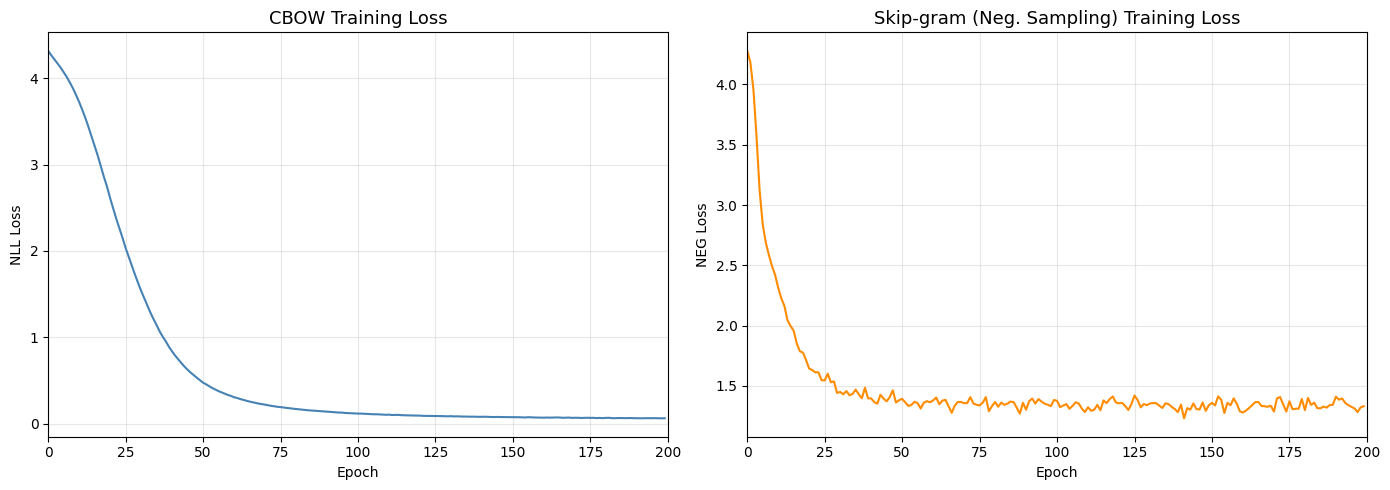

In [0]:
# ============================================================
# TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CBOW loss
axes[0].plot(cbow_losses, color='steelblue', linewidth=1.5)
axes[0].set_title('CBOW Training Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('NLL Loss')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, len(cbow_losses))

# Skip-gram loss
axes[1].plot(skipgram_losses, color='darkorange', linewidth=1.5)
axes[1].set_title('Skip-gram (Neg. Sampling) Training Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('NEG Loss')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, len(skipgram_losses))

plt.tight_layout()
plt.show()

In [0]:
# ============================================================
# EMBEDDING EVALUATION: SIMILARITY & ANALOGIES
# ============================================================

def cosine_similarity(v1: np.ndarray, v2: np.ndarray) -> float:
    """Compute cosine similarity between two vectors."""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)


def find_most_similar(word: str, model, word2idx: Dict, idx2word: Dict, top_k: int = 5):
    """Find the top-k most similar words to a query word."""
    if word not in word2idx:
        print(f"'{word}' not in vocabulary!")
        return
    
    word_vec = model.get_embedding(word2idx[word])
    all_embeddings = model.get_all_embeddings()
    
    # Compute similarities with all words
    similarities = []
    for idx in range(len(all_embeddings)):
        if idx == word2idx[word]:
            continue
        sim = cosine_similarity(word_vec, all_embeddings[idx])
        similarities.append((idx2word[idx], sim))
    
    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\nMost similar to '{word}':")
    for w, sim in similarities[:top_k]:
        print(f"  {w:<12} {sim:.4f}")


def word_analogy(a: str, b: str, c: str, model, word2idx: Dict, idx2word: Dict):
    """
    Solve analogy: a is to b as c is to ?
    
    Uses the famous vector arithmetic: vec(b) - vec(a) + vec(c) ≈ vec(?)
    
    Example: king - man + woman ≈ queen
    """
    if any(w not in word2idx for w in [a, b, c]):
        print(f"Some words not in vocabulary!")
        return
    
    vec_a = model.get_embedding(word2idx[a])
    vec_b = model.get_embedding(word2idx[b])
    vec_c = model.get_embedding(word2idx[c])
    
    # Analogy vector
    target_vec = vec_b - vec_a + vec_c
    
    # Find closest word (excluding a, b, c)
    all_embeddings = model.get_all_embeddings()
    exclude = {word2idx[a], word2idx[b], word2idx[c]}
    
    best_word = None
    best_sim = -np.inf
    
    for idx in range(len(all_embeddings)):
        if idx in exclude:
            continue
        sim = cosine_similarity(target_vec, all_embeddings[idx])
        if sim > best_sim:
            best_sim = sim
            best_word = idx2word[idx]
    
    print(f"  {a} : {b} :: {c} : {best_word} (similarity: {best_sim:.4f})")


# --- Evaluate CBOW embeddings ---
print("=" * 60)
print("CBOW EMBEDDINGS - Evaluation")
print("=" * 60)

for word in ['king', 'queen', 'man', 'woman']:
    find_most_similar(word, cbow_model, word2idx, idx2word)

print("\n--- Analogies (CBOW) ---")
word_analogy('king', 'queen', 'man', cbow_model, word2idx, idx2word)
word_analogy('man', 'woman', 'boy', cbow_model, word2idx, idx2word)
word_analogy('king', 'prince', 'queen', cbow_model, word2idx, idx2word)

# --- Evaluate Skip-gram embeddings ---
print("\n" + "=" * 60)
print("SKIP-GRAM EMBEDDINGS - Evaluation")
print("=" * 60)

for word in ['king', 'queen', 'man', 'woman']:
    find_most_similar(word, skipgram_model, word2idx, idx2word)

print("\n--- Analogies (Skip-gram) ---")
word_analogy('king', 'queen', 'man', skipgram_model, word2idx, idx2word)
word_analogy('man', 'woman', 'boy', skipgram_model, word2idx, idx2word)
word_analogy('king', 'prince', 'queen', skipgram_model, word2idx, idx2word)

CBOW EMBEDDINGS - Evaluation

Most similar to 'king':
  great        0.3851
  power        0.3302
  queen        0.3278
  princess     0.2871
  prince       0.2735

Most similar to 'queen':
  garden       0.6354
  play         0.5088
  should       0.4646
  every        0.3791
  prince       0.3595

Most similar to 'man':
  grows        0.4645
  wise         0.4160
  woman        0.3945
  needs        0.3367
  over         0.3308

Most similar to 'woman':
  man          0.3945
  strong       0.3528
  be           0.3267
  grows        0.3217
  needs        0.3183

--- Analogies (CBOW) ---
  king : queen :: man : garden (similarity: 0.4729)
  man : woman :: boy : girl (similarity: 0.4951)
  king : prince :: queen : play (similarity: 0.4315)

SKIP-GRAM EMBEDDINGS - Evaluation

Most similar to 'king':
  queen        0.6525
  needs        0.5865
  studies      0.5063
  trains       0.4620
  will         0.4413

Most similar to 'queen':
  king         0.6525
  power        0.5148
  great   

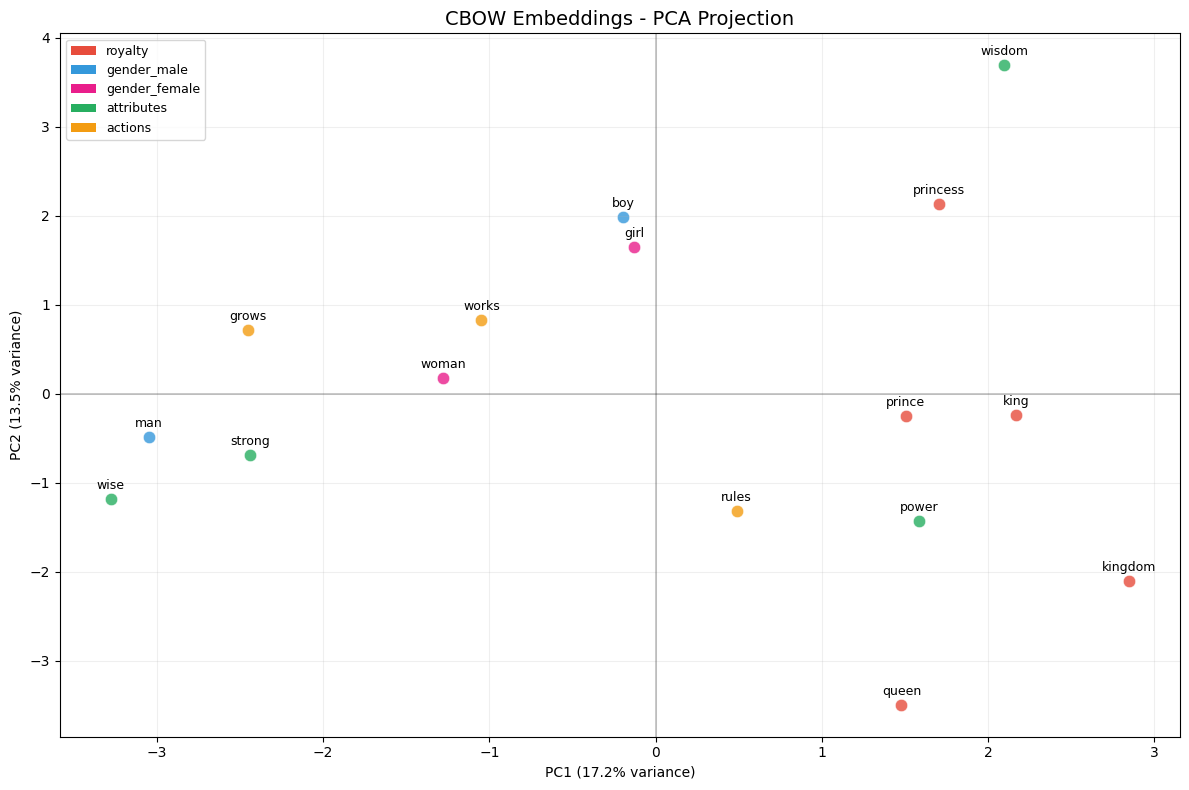

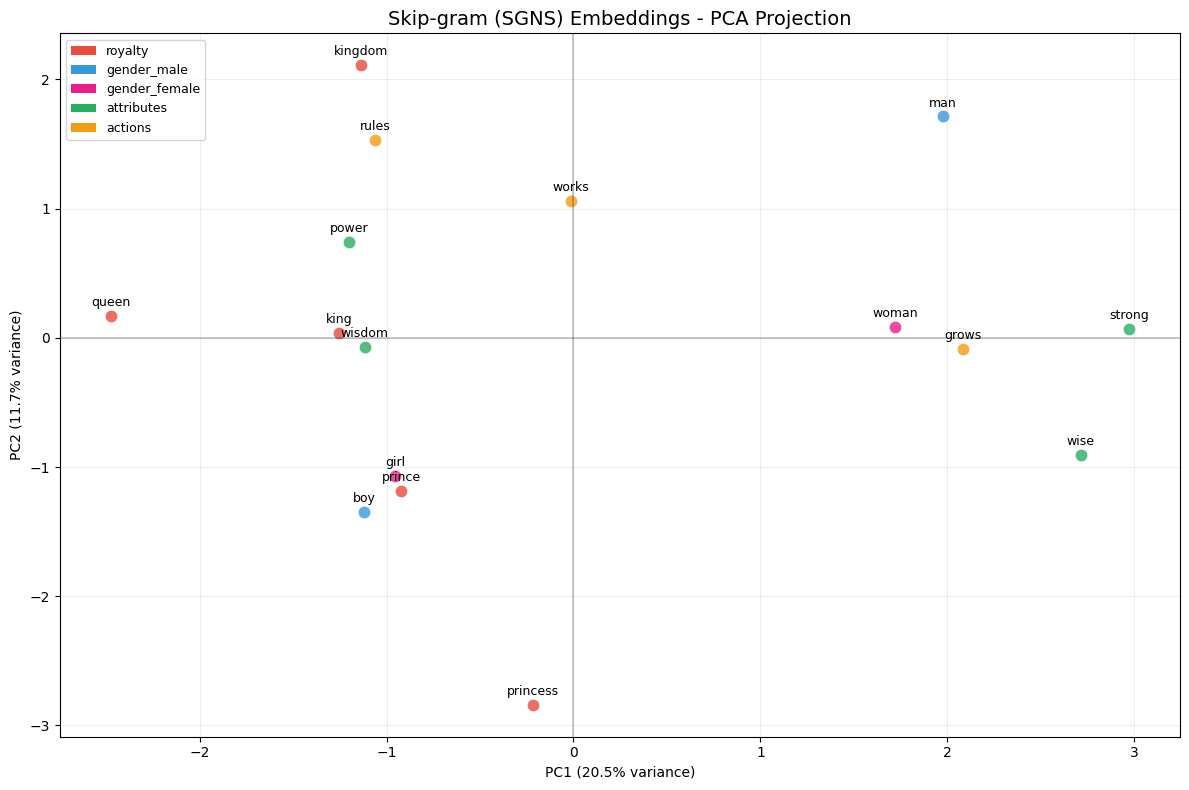

In [0]:
# ============================================================
# VISUALIZATION: PCA PROJECTION OF EMBEDDINGS
# ============================================================

def plot_embeddings(model, word2idx, idx2word, words_to_plot=None, title="Word Embeddings (PCA)"):
    """
    Project embeddings to 2D using PCA and visualize.
    """
    all_embeddings = model.get_all_embeddings()
    
    if words_to_plot is None:
        words_to_plot = list(word2idx.keys())
    
    # Filter to words in vocabulary
    words_to_plot = [w for w in words_to_plot if w in word2idx]
    indices = [word2idx[w] for w in words_to_plot]
    embeddings_subset = all_embeddings[indices]
    
    # PCA to 2D
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings_subset)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Color groups for visualization
    color_map = {
        'royalty': ['king', 'queen', 'prince', 'princess', 'kingdom', 'castle'],
        'gender_male': ['man', 'boy', 'men'],
        'gender_female': ['woman', 'girl', 'women'],
        'attributes': ['wisdom', 'power', 'strong', 'wise', 'grace'],
        'actions': ['rules', 'rule', 'works', 'grows', 'play', 'trains', 'studies'],
    }
    
    # Invert: word -> color
    word_colors = {}
    colors = ['#e74c3c', '#3498db', '#e91e8b', '#27ae60', '#f39c12']
    for (group, words), color in zip(color_map.items(), colors):
        for w in words:
            word_colors[w] = (color, group)
    
    # Plot each word
    plotted_groups = set()
    for i, word in enumerate(words_to_plot):
        color, group = word_colors.get(word, ('#95a5a6', 'other'))
        label = group if group not in plotted_groups else None
        plotted_groups.add(group)
        
        ax.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], 
                  c=color, s=80, alpha=0.8, edgecolors='white', linewidth=0.5)
        ax.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                   fontsize=9, ha='center', va='bottom', 
                   xytext=(0, 5), textcoords='offset points')
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='k', linewidth=0.3)
    ax.axvline(x=0, color='k', linewidth=0.3)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=g) for g, c in zip(
        color_map.keys(), colors)]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.show()


# Words to visualize
visualize_words = [
    'king', 'queen', 'prince', 'princess', 'kingdom',
    'man', 'woman', 'boy', 'girl',
    'wisdom', 'power', 'strong', 'wise',
    'rules', 'works', 'grows'
]

plot_embeddings(cbow_model, word2idx, idx2word, visualize_words, 
               title="CBOW Embeddings - PCA Projection")

plot_embeddings(skipgram_model, word2idx, idx2word, visualize_words,
               title="Skip-gram (SGNS) Embeddings - PCA Projection")

## 6. The Implicit Matrix Factorization Perspective

Levy & Goldberg (2014) proved a remarkable result: **Skip-gram with Negative Sampling (SGNS) implicitly factorizes the word-context PMI matrix.**

Specifically, when SGNS converges optimally:

$$\mathbf{v}_w^\top \mathbf{v'}_c = \text{PMI}(w, c) - \log K$$

where:
* $$\text{PMI}(w,c) = \log \frac{P(w,c)}{P(w) \cdot P(c)}$$ is the Pointwise Mutual Information
* $$K$$ is the number of negative samples

This means Word2Vec is a **compressed, noise-contrastive approximation** to a word co-occurrence PMI matrix. The vectors encode distributional statistics in a factored form.

### Why This Matters

This connection explains:
1. **Why larger corpora help** — Better PMI estimates
2. **Why negative sampling works** — It approximates the PMI objective
3. **Why vector arithmetic captures analogies** — Linear relationships in PMI space correspond to relational patterns
4. **Why GloVe and Word2Vec are similar** — Both factorize co-occurrence matrices, just with different weighting schemes

In [0]:
# ============================================================
# PRODUCTION-QUALITY IMPLEMENTATION: FULL PIPELINE
# with Subsampling, Dynamic Window, and Learning Rate Decay
# ============================================================

class Word2VecTrainer:
    """
    A complete Word2Vec training pipeline implementing all tricks
    from the original paper:
    - Subsampling of frequent words
    - Dynamic (randomized) window size
    - Learning rate linear decay
    - Negative sampling with f^(3/4) distribution
    """
    
    def __init__(self, corpus: List[str], embedding_dim: int = 100, 
                 window_size: int = 5, min_count: int = 1,
                 num_negatives: int = 5, subsample_threshold: float = 1e-3,
                 architecture: str = 'skipgram'):
        
        self.embedding_dim = embedding_dim
        self.window_size = window_size
        self.num_negatives = num_negatives
        self.subsample_threshold = subsample_threshold
        self.architecture = architecture
        
        # Build vocabulary
        self._build_vocab(corpus, min_count)
        
        # Compute subsampling probabilities
        self._compute_subsample_probs()
        
        # Build noise distribution
        self._build_noise_distribution()
        
        # Initialize model
        if architecture == 'skipgram':
            self.model = SkipGramNegativeSampling(self.vocab_size, embedding_dim)
        else:
            self.model = CBOW(self.vocab_size, embedding_dim)
        
        print(f"Word2Vec Trainer initialized:")
        print(f"  Architecture: {architecture}")
        print(f"  Vocabulary: {self.vocab_size} words")
        print(f"  Embedding dim: {embedding_dim}")
        print(f"  Window size: {window_size}")
        print(f"  Negative samples: {num_negatives}")
    
    def _build_vocab(self, corpus, min_count):
        """Build vocabulary with frequency filtering."""
        tokenized = [s.lower().split() for s in corpus]
        word_counts = Counter(w for s in tokenized for w in s)
        
        # Filter and sort by frequency (most frequent first)
        self.vocab = sorted(
            [(w, c) for w, c in word_counts.items() if c >= min_count],
            key=lambda x: -x[1]
        )
        self.word2idx = {w: i for i, (w, _) in enumerate(self.vocab)}
        self.idx2word = {i: w for w, i in self.word2idx.items()}
        self.vocab_size = len(self.word2idx)
        self.word_freqs = np.array([c for _, c in self.vocab], dtype=np.float64)
        self.total_words = self.word_freqs.sum()
        
        # Encode corpus
        self.encoded_corpus = [
            [self.word2idx[w] for w in s if w in self.word2idx]
            for s in tokenized
        ]
    
    def _compute_subsample_probs(self):
        """
        Compute the probability of KEEPING each word.
        P(keep w) = sqrt(t / f(w))   [capped at 1.0]
        where f(w) = count(w) / total_words
        """
        freqs = self.word_freqs / self.total_words
        self.keep_probs = np.minimum(
            np.sqrt(self.subsample_threshold / freqs) + 
            (self.subsample_threshold / freqs),
            1.0
        )
    
    def _build_noise_distribution(self):
        """Build f^(3/4) noise distribution for negative sampling."""
        powered = self.word_freqs ** 0.75
        self.noise_dist = powered / powered.sum()
    
    def _subsample_sentence(self, sentence_indices: List[int]) -> List[int]:
        """Apply subsampling: randomly discard frequent words."""
        return [idx for idx in sentence_indices 
                if np.random.random() < self.keep_probs[idx]]
    
    def _get_dynamic_window(self) -> int:
        """Randomly reduce window size (equivalent to distance-weighting)."""
        return np.random.randint(1, self.window_size + 1)
    
    def most_similar(self, word: str, top_k: int = 5):
        """Find most similar words by cosine similarity."""
        if word not in self.word2idx:
            print(f"'{word}' not in vocabulary")
            return []
        
        embeddings = self.model.get_all_embeddings()
        word_vec = embeddings[self.word2idx[word]]
        
        # Normalize all embeddings
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-10
        normalized = embeddings / norms
        word_vec_norm = word_vec / (np.linalg.norm(word_vec) + 1e-10)
        
        # Compute all similarities at once
        similarities = normalized @ word_vec_norm
        
        # Get top-k (excluding the word itself)
        top_indices = np.argsort(-similarities)
        results = []
        for idx in top_indices:
            if idx != self.word2idx[word]:
                results.append((self.idx2word[idx], similarities[idx]))
                if len(results) == top_k:
                    break
        
        return results


# Create a production-quality trainer
trainer = Word2VecTrainer(
    corpus=corpus,
    embedding_dim=50,
    window_size=3,
    min_count=1,
    num_negatives=5,
    architecture='skipgram'
)

# Show subsampling effect
print("\nSubsampling probabilities (P_keep) for top words:")
print(f"{'Word':<12} {'Frequency':<10} {'P(keep)':<10}")
print("-" * 35)
for i in range(min(10, trainer.vocab_size)):
    word, count = trainer.vocab[i]
    print(f"{word:<12} {count:<10} {trainer.keep_probs[i]:<10.4f}")

Word2Vec Trainer initialized:
  Architecture: skipgram
  Vocabulary: 66 words
  Embedding dim: 50
  Window size: 3
  Negative samples: 5

Subsampling probabilities (P_keep) for top words:
Word         Frequency  P(keep)   
-----------------------------------
the          23         0.0942    
a            11         0.1411    
and          10         0.1488    
king         7          0.1819    
queen        7          0.1819    
kingdom      6          0.1986    
wisdom       5          0.2206    
every        5          0.2206    
with         4          0.2512    
day          4          0.2512    


## 7. Industrial Applications — The Word2Vec Paradigm Beyond Text

The genius of Word2Vec is not limited to words. The core principle — **learning dense representations from sequential co-occurrence** — can be applied to ANY domain where entities appear in sequences or contexts. This has spawned an entire class of "X2Vec" methods.

---

### 7.1 E-Commerce & Recommendations

| Method | "Words" = | "Sentences" = | Application |
| --- | --- | --- | --- |
| **Prod2Vec** (Airbnb, 2018) | Products/Listings | User browsing sessions | Similar item recommendations |
| **Item2Vec** (Microsoft, 2016) | Items | User purchase baskets | "Customers who bought X also bought Y" |
| **Query2Vec** | Search queries | User search sessions | Query suggestion, auto-complete |
| **Listing2Vec** (Airbnb) | Airbnb listings | User click sequences | Personalized search ranking |

**How it works (Prod2Vec):**
- Treat each user's clickstream as a "sentence": `[product_A, product_B, product_C, ...]`
- Train Skip-gram on these sequences
- Products clicked in similar contexts get similar embeddings
- Result: semantically meaningful product similarity without feature engineering

---

### 7.2 Graph & Network Embeddings

| Method | "Words" = | "Sentences" = | Application |
| --- | --- | --- | --- |
| **DeepWalk** (2014) | Graph nodes | Random walks on graph | Social network analysis |
| **Node2Vec** (2016) | Graph nodes | Biased random walks (BFS/DFS) | Link prediction, community detection |
| **Metapath2Vec** (2017) | Heterogeneous nodes | Meta-path guided walks | Knowledge graph completion |

**How it works (Node2Vec):**
- Generate random walks from each node in the graph
- Random walk = sequence of nodes = "sentence"
- Apply Skip-gram to learn node embeddings
- Tune BFS vs DFS bias to capture structural vs community similarity

---

### 7.3 Genomics & Healthcare

| Method | "Words" = | "Sentences" = | Application |
| --- | --- | --- | --- |
| **DNA2Vec** | DNA k-mers | Genomic sequences | Gene similarity, mutation effects |
| **Med2Vec** | Medical codes (ICD) | Patient visit sequences | Disease prediction, patient similarity |
| **Drug2Vec** | Drugs | Co-prescription patterns | Drug interaction prediction |
| **Prot2Vec** | Amino acid n-grams | Protein sequences | Protein function prediction |

---

### 7.4 Music, Media & Content

| Method | "Words" = | "Sentences" = | Application |
| --- | --- | --- | --- |
| **Song2Vec** (Spotify) | Songs | Playlists / listening sessions | Music recommendations |
| **Doc2Vec / Paragraph Vectors** | Documents | - (extension of W2V) | Document similarity, classification |
| **Video2Vec** (YouTube) | Videos | Watch sessions | Video recommendations |

---

### 7.5 Code & Software Engineering

| Method | "Words" = | "Sentences" = | Application |
| --- | --- | --- | --- |
| **Code2Vec** | AST path contexts | Method bodies | Code understanding, naming |
| **API2Vec** | API calls | Call sequences | API recommendation |
| **Commit2Vec** | Code changes | Repository histories | Bug prediction |

---

### 7.6 Security & Fraud

| Method | "Words" = | "Sentences" = | Application |
| --- | --- | --- | --- |
| **IP2Vec** | IP addresses | Network flow sequences | Anomaly/intrusion detection |
| **Transaction2Vec** | Transaction types | User transaction histories | Fraud pattern detection |
| **Malware2Vec** | API/system calls | Malware execution traces | Malware classification |

## 8. How to Model ANY Domain as a Word2Vec Pipeline

The recipe for applying the Word2Vec paradigm to a new domain follows a systematic pattern:

### The Universal Recipe

```
1. DEFINE YOUR "VOCABULARY"
   What are the discrete entities you want embeddings for?
   (products, users, genes, nodes, songs, API calls, ...)

2. DEFINE YOUR "SENTENCES" / SEQUENCES
   What constitutes a meaningful co-occurrence context?
   (clickstreams, playlists, random walks, call traces, ...)

3. DEFINE YOUR "WINDOW"
   How far should context extend?
   (immediate neighbors, full session, time-bounded, ...)

4. TRAIN WORD2VEC (Skip-gram + Neg. Sampling)
   Apply standard SGNS on your constructed sequences.

5. USE THE EMBEDDINGS
   Similarity search, clustering, downstream ML features, etc.
```

### Design Decisions That Matter

| Decision | Impact | Guidance |
| --- | --- | --- |
| Window size | Larger → topical similarity; Smaller → functional similarity | Start with 5, tune |
| Embedding dim | Larger → more expressive, needs more data | 64–256 for most applications |
| Negative samples | More → better for small data, slower | K=5–20 |
| Min count | Filter noise, reduce vocabulary | Domain-dependent |
| Subsampling | Critical for power-law distributions | Always use for user behavior data |
| Sequence construction | THE most important design choice | Domain expertise required |

### When Word2Vec-Style Training Works Best

1. **Sequential data** exists naturally (user journeys, playlists, walks)
2. **Co-occurrence implies similarity** (items bought together are related)
3. **Vocabulary is discrete and finite** (products, songs, codes)
4. **Scale is large** (millions of sequences, thousands of entities)
5. **Unsupervised is acceptable** (no labels needed)

### When It Fails

1. **No natural sequence** exists (static feature sets)
2. **Order doesn't matter** (bag-of-features is sufficient)
3. **Relationships are not symmetric** (hierarchical data needs special handling)
4. **Very small data** (< 10K sequences → matrix factorization may be better)

---

### Real-World Case Study: Airbnb's Listing Embeddings (2018)

Airbnb's approach demonstrates the full pipeline:

1. **Vocabulary** = 4.5M unique listings
2. **Sentences** = User booking sessions (clicked listings in order)
3. **Special handling**:
   - Booked listing added as a global context (always in window)
   - Market (city) used for "congregating" embeddings (listings in same city should be closer)
   - Explicit negatives from user rejections (listings seen but not booked)
4. **Training** = Skip-gram with modifications
5. **Result** = 99% of search ranking improvement came from these embeddings alone

---

## Summary & Key Takeaways

* Word2Vec learns $$d$$-dimensional dense vectors from raw co-occurrence statistics
* **CBOW** averages context embeddings to predict the center word (fast, good for frequent words)
* **Skip-gram** uses the center word to predict each context word (better for rare words)
* **Negative Sampling** reduces complexity from $$O(V)$$ to $$O(K)$$ per sample
* Mathematically, SGNS ≈ factorizing the shifted PMI matrix
* The paradigm generalizes to ANY domain with sequential co-occurrence data
* Industrial applications span e-commerce, graphs, genomics, music, code, and security

---

### References

1. Mikolov et al. (2013) — *Efficient Estimation of Word Representations in Vector Space*
2. Mikolov et al. (2013) — *Distributed Representations of Words and Phrases and their Compositionality*
3. Levy & Goldberg (2014) — *Neural Word Embedding as Implicit Matrix Factorization*
4. Grbovic et al. (2018) — *Real-time Personalization using Embeddings for Search Ranking at Airbnb*
5. Grover & Leskovec (2016) — *node2vec: Scalable Feature Learning for Networks*
6. Barkan & Koenigstein (2016) — *Item2Vec: Neural Item Embedding for Collaborative Filtering*